# Nhóm 7, Notebook_A (Sinh viên A): dữ liệu, EDA, làm sạch, SQL, hình RQ1

**Đề tài**: Sự cố UAS đa phương thức và tóm tắt nhanh (NASA ASRS)

**Khung SDG**: SDG 9: hạ tầng hàng không an toàn, "the industrial internet"; tiêu đề, keyword và abstract của bài dùng đúng cụm từ này.

**Vai trò**: Sinh viên A làm Bước 0 đến 3 và phần hình RQ1 của Bước 5, bàn giao `data/processed/feat.parquet` cùng `manifest.json` cho Sinh viên B (Notebook_B). Chạy tuần tự trong VS Code với extension Python và Jupyter, interpreter `.venv`. Mỗi bước có ô hướng dẫn *làm gì, vì sao, đọc thế nào* rồi đến ô code; mọi bảng lưu vào `report/` với tên `table_*.csv`, mọi hình `fig_*.png`.

**Quy tắc**: seed 42; không xoá dòng mà không ghi lý do; mọi prompt AI ghi vào Audit Log cá nhân; báo cáo slot 1 thứ Ba và thứ Sáu theo mẫu ở ô cuối.

## Vừa làm vừa hỏi AI và ghi Audit Log: cách làm nhẹ nhàng, không rối

**Tinh thần**: AI là bạn cùng làm, không phải người làm thay. Bạn được hỏi AI bất cứ lúc nào; điều duy nhất phải giữ là *kiểm tra một lần* trước khi dùng và *ghi lại 2 phút* nếu câu hỏi đó thay đổi việc bạn làm.

**Khi nào hỏi AI** (theo thứ tự):
1. Đọc ô hướng dẫn của bước đang làm (1 phút).
2. Thử tự làm 15 phút.
3. Bí quá 15 phút thì hỏi AI với mẫu: *"Tôi đang làm Bước X của dự án Y. Dữ liệu có cột A, B, C. Tôi muốn Z. Đây là code và lỗi: ... Hãy giải thích nguyên nhân và sửa, giữ nguyên tên biến."*
4. Chạy thử code AI đưa trên dữ liệu thật; so một con số bằng tay hoặc bằng cách thứ hai.
5. Nếu vẫn bí sau 30 phút, ghi lại lỗi và hỏi giảng viên ở kênh nhóm.

**Ghi Audit Log thế nào cho không áp lực**: chỉ ghi các prompt *đã thay đổi việc bạn làm* (thường 3 đến 5 prompt một tuần, 15 đến 20 cả kỳ). Mỗi dòng 5 ô, điền trong 2 phút ngay khi dùng, không để cuối tuần:

| Ngày, bước | Prompt (rút gọn) | AI trả lời gì (1 dòng) | Tôi kiểm tra hoặc sửa gì | Dùng vào đâu |
|---|---|---|---|---|
| 09/09, Bước 3 | viết truy vấn trung bình trượt 7 ngày theo trạm | đưa AVG OVER ROWS 6 PRECEDING | thiếu PARTITION BY site_num, thêm và thử 2 trạm | Q3 trong sql/queries.sql |

Cột thứ tư chính là *Human Delta* và là thứ hội đồng hỏi; ghi thật, kể cả khi AI đúng ("kiểm tra bằng 10 dòng tính tay, khớp"). Ba lần bạn phát hiện AI sai trong cả kỳ là đủ yêu cầu.

**Nhịp làm việc**: mỗi ngày 1,5 đến 2 giờ vào đúng bước của tuần, xong một ô thì commit; thứ Ba và thứ Sáu slot 1 báo cáo năm mục đúng tiến độ, dù kết quả chưa đẹp. Siêng và đúng nhịp quan trọng hơn giỏi: nhóm báo cáo đều 6 lần trong 3 tuần luôn có bài, nhóm im lặng đến tuần 3 thường không kịp.

In [36]:
import os
import shutil
import duckdb
from pathlib import Path

# 1. Tìm chính xác thư mục gốc dự án (thư mục chứa file asrs_2019_2024.csv)
current = Path.cwd()
project_root = current
while project_root.name and project_root.name != "Group6_ADY201m_FA26_AI2108":
    if (project_root / "asrs_2019_2024.csv").exists():
        break
    project_root = project_root.parent

# 2. Định vị thư mục data/raw ở cấp gốc dự án
raw_dir = project_root / "data" / "raw"
processed_dir = project_root / "data" / "processed"
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)
# 3. Tìm và chuyển file CSV
csv_name = "asrs_2019_2024.csv"
source_file = project_root / csv_name
target_file = raw_dir / csv_name

if source_file.exists():
    shutil.move(str(source_file), str(target_file))
    print(f"Đã chuyển thành công {csv_name} vào {raw_dir}")
elif target_file.exists():
    print(f"File {csv_name} đã nằm sẵn trong {raw_dir}")
else:
    print(f"Không tìm thấy {csv_name} tại {project_root}")

# 4. Tạo đường dẫn đọc file cho DuckDB
search_pattern = str(raw_dir / "*.csv").replace("\\", "/")

# 5. Đọc dữ liệu vào bảng feat trong DuckDB
con = duckdb.connect()
df = con.execute(f"""
    CREATE OR REPLACE TABLE feat AS 
    SELECT * 
    FROM read_csv_auto('{search_pattern}', union_by_name=true, header=true)
""").df()

# 6. Chuẩn hóa tên cột
df.columns = [c.strip().lower().replace(' ', '_').replace('.', '_') for c in df.columns]
df = df.rename(columns={'acn': 'id', 'report_1': 'narrative', 'anomaly': 'anomaly'})

# 7. Tạo cột is_uas an toàn
if 'aircraft_operator' in df.columns:
    df['is_uas'] = df['aircraft_operator'].fillna('').astype(str).str.contains('uas', case=False)
else:
    df['is_uas'] = False

# 8. Cập nhật lại DuckDB với dữ liệu đã chuẩn hóa
con.execute("CREATE OR REPLACE TABLE feat AS SELECT * FROM df")

print("----------------------------------------")
print("Nạp dữ liệu vào DuckDB thành công!")
print(f"Kích thước dữ liệu: {df.shape}")

File asrs_2019_2024.csv đã nằm sẵn trong c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\data\raw
----------------------------------------
Nạp dữ liệu vào DuckDB thành công!
Kích thước dữ liệu: (1, 2)


In [3]:
%pip install duckdb pandas numpy matplotlib


  Using cached duckdb-1.5.5-cp312-cp312-win_amd64.whl.metadata (4.2 kB)
  Using cached pandas-3.0.5-cp312-cp312-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.5.3-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached matplotlib-3.11.1-cp312-cp312-win_amd64.whl.metadata (80 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.65.0-cp312-cp312-win_amd64.whl.metadata (127 kB)
  Using cached kiwisolver-1.5.1-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached duckdb-1.5.5-cp312-cp312-win_amd64.whl (13.2 MB)
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.8 MB ? eta -:--:--
   --- -----


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pathlib
import warnings
import duckdb
import pandas as pd

warnings.filterwarnings('ignore')

# Tự động tạo cấu trúc thư mục nếu chưa có
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']:
  pathlib.Path(d).mkdir(parents=True, exist_ok=True)

# Thiết lập seed cố định và cấu hình hiển thị
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)

# Kiểm tra phiên bản thư viện đã cài đặt thành công
print('pandas:', pd.__version__, '| duckdb:', duckdb.__version__)

pandas: 2.3.3 | duckdb: 1.5.5


## Bước 0: môi trường và cấu trúc thư mục

Chạy một lần trong Terminal của VS Code, không phải trong ô Python. Sau khi cài xong chọn interpreter `.venv` (Ctrl+Shift+P, *Python: Select Interpreter*).

```bash
# Step 1a: environment and project layout (run once)
python -m venv .venv && source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install pandas numpy duckdb pyarrow scikit-learn lightgbm xgboost catboost \
    statsmodels shap matplotlib seaborn ydata-profiling mapie jupyter
pip freeze > requirements.txt
mkdir -p data/raw data/processed notebooks sql src report
printf "data/raw\ndata/processed\n.venv\n*.parquet\n" > .gitignore
```

In [4]:
# Environment check and shared imports for the whole notebook
import pandas as pd, numpy as np, duckdb, matplotlib
import matplotlib.pyplot as plt, pathlib, warnings
warnings.filterwarnings('ignore')
for d in ['data/raw', 'data/processed', 'notebooks', 'sql', 'src', 'report']: pathlib.Path(d).mkdir(parents=True, exist_ok=True)
np.random.seed(42); pd.set_option('display.width', 160); pd.set_option('display.max_columns', 40)
print('pandas', pd.__version__, '| duckdb', duckdb.__version__)

pandas 2.3.3 | duckdb 1.5.5


## Vì sao sáu bước và mỗi bước giúp gì cho bài

| Bước | Mục đích | Lợi ích cho bài | Bằng chứng, câu hỏi |
|---|---|---|---|
| 1 Nạp, hiểu dữ liệu | biết quy mô, thời gian, đơn vị, mục tiêu | bảng mô tả dữ liệu, phạm vi hợp lệ | table_describe, profile; nền mọi RQ |
| 2 Làm sạch, ghép | dữ liệu tin được, có nguồn thứ hai | nhật ký làm sạch trả lời phản biện; đặc trưng ngoại sinh | cleaning_log, tỷ lệ khớp; RQ1, RQ2 |
| 3 SQL, EDA | trả lời câu hỏi mô tả bằng số có kiểm định; đặc trưng đúng thời điểm | bảng RQ1 có p-value; không rò rỉ; điểm SQL | table_q*, rq1a-c; RQ1 |
| 4 Chia dữ liệu | đánh giá công bằng | mốc naive cho biết cải thiện thật | table_features; RQ2 |
| 5 Trực quan hoá | thấy cấu trúc và bất thường; truyền đạt | hình có caption kết luận | fig_rq1_*; RQ1 |
| 6 Mô hình, RQ3 | so năm mô hình công bằng; đóng góp chính | bảng có độ lệch, tinh chỉnh có căn cứ, SHAP | table_rq2, rq3; RQ2, RQ3 |

**Vì sao phải chọn cột từ nhiều cột**: cột thừa làm mô hình học nhiễu, cột chứa giá trị tương lai làm kết quả đẹp giả, cột không có lúc vận hành làm mô hình vô dụng. Bốn bước giúp chọn đúng cột và khớp RQ: (1) tài liệu cơ quan cho biết ý nghĩa vật lý; (2) bảng thiếu và bảng tương quan trong EDA loại cột thiếu nhiều hoặc trùng; (3) SQL với LAG/LEAD tách quá khứ khỏi tương lai; (4) SHAP sau mô hình xác nhận cột thực sự đóng góp. Mỗi cột giữ lại phải nối về một RQ: cột mô tả cho RQ1, cột dự báo cho RQ2, cột nhóm hoặc điều kiện cho RQ3.

## Bước 1: hiểu bài toán và nạp dữ liệu

### 1.1. Bài toán và ba câu hỏi

Ghi lại ở đây ba câu hỏi nghiên cứu của đề cương (RQ1 mô tả, RQ2 mô hình, RQ3 câu hỏi thứ ba) và biến mục tiêu; mọi bảng và hình sau này phải nối về một trong ba câu hỏi.

**Làm gì**: tải file gốc từ trang cơ quan vào `data/raw/`, nạp bằng DuckDB (đọc thẳng file từ đĩa, chỉ lấy cột và dòng cần) rồi in số dòng, số cột, khoảng thời gian, số đơn vị.

**Kiểm tra**: `df.shape` khớp tài liệu cơ quan; khoảng thời gian đúng; số đơn vị đúng phạm vi đề cương.

In [5]:
# Step 1b: merge yearly CSV exports from ASRS
import duckdb, pandas as pd
from pathlib import Path

# 1. Tự động tìm vị trí thư mục data/raw chứa file CSV
possible_paths = [
    Path.cwd().parent / "data" / "raw",       # Dạng ../data/raw
    Path.cwd() / "data" / "raw",              # Dạng ./data/raw
    Path.cwd().parent.parent / "data" / "raw" # Dạng '../../data/raw
]

raw_dir = None
for p in possible_paths:
    if p.exists() and len(list(p.glob("*.csv"))) > 0:
        raw_dir = p
        break

if not raw_dir:
    root = Path.cwd()
    while root.name and root.name != "Group6_ADY201m_FA26_AI2108":
        root = root.parent

    target_dir = root / "data" / "raw"
    target_dir.mkdir(parents=True, exist_ok=True)

    csv_src = root / "asrs_2019_2024.csv"
    if csv_src.exists():
        import shutil
        shutil.move(str(csv_src), str(target_dir / "asrs_2019_2024.csv"))
    raw_dir = target_dir

# 2. Tạo đường dẫn quét TẤT CẢ các file .csv trong dự án
    search_pattern = str(raw_dir / "*.csv").replace("\\", "/")
# 3. Đọc dữ liệu
con = duckdb.connect()
df = con.execute(f"""
    CREATE OR REPLACE TABLE feat AS 
    SELECT * 
    FROM read_csv_auto('{search_pattern}', union_by_name=true, header=true)
""").df()

# 4. Chuẩn hóa tên cột
df.columns = [c.strip().lower().replace(' ', '_').replace('.', '_') for c in df.columns]
df = df.rename(columns={'acn': 'id', 'report_1': 'narrative', 'anomaly': 'anomaly'})

# Kiểm tra và xử lý cột aircraft_operator an toàn
if 'aircraft_operator' in df.columns:
    df['is_uas'] = df['aircraft_operator'].fillna('').astype(str).str.contains('uas', case=False)
else:
    df['is_uas'] = False

# 5. Cập nhật lại DuckDB
con.execute("CREATE OR REPLACE TABLE feat AS SELECT * FROM df")

print("✅ Nạp dữ liệu thành công!")
print("Kích thước dữ liệu:", df.shape)
print("Tỷ lệ UAS:", df['is_uas'].mean().round(3))

✅ Nạp dữ liệu thành công!
Kích thước dữ liệu: (1, 2)
Tỷ lệ UAS: 0.0


### 1.1b. Hồ sơ tự động

`ydata-profiling` trên mẫu 20 nghìn dòng tạo `report/profile.html`; mở bằng trình duyệt để xem nhanh phân phối, thiếu, tương quan trước khi tự viết EDA ở các ô sau.

In [1]:
%pip install ydata-profiling --no-cache-dir

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.0 MB 3.7 MB/s eta 0:00:02
   ------- -------------------------------- 1.6/8.0 MB 4.0 MB/s eta 0:00:02
   ----------- ---------------------------- 2.4/8.0 MB 3.8 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 3.5 MB/s eta 0:00:02
   ------------------- -------------------- 3.9/8.0 MB 3.7 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 3.5 MB/s eta 0:00:02
   -------------------------- ------------- 5.2/8.0 MB 3.5 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 3.6 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.0 MB 3.6 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.0 MB 3.6 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 3.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
    ---------------------


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
%pip install setuptools

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
from pathlib import Path

# 1. Định vị thư mục report
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists():
            return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# 2. Xuất table_describe_raw.csv chuẩn
df.describe(include='all').T.to_csv(str(report_dir / 'table_describe_raw.csv'))

# 3. Thử dùng ydata_profiling, nếu lỗi môi trường sẽ dùng fallback
try:
    from ydata_profiling import ProfileReport
    sample = df.sample(min(20000, len(df)), random_state=42)
    ProfileReport(sample, minimal=True).to_file(str(report_dir / 'profile.html'))
    print("✅ Đã tạo profile.html bằng ydata-profiling!")
except Exception as e:
    # Phương án dự phòng tạo profile.html nếu thư viện lỗi
    profile_info = df.describe(include='all').T.to_html()
    with open(report_dir / 'profile.html', 'w', encoding='utf-8') as f:
        f.write(f"<h1>Data Summary Profile</h1>{profile_info}")
    print(f"⚠️ ydata-profiling bị lỗi môi trường ({e}). Đã dùng phương án dự phòng xuất profile.html!")

print("✅ Đã tạo thành công table_describe_raw.csv trong thư mục report!")

⚠️ ydata-profiling bị lỗi môi trường (No module named 'pkg_resources'). Đã dùng phương án dự phòng xuất profile.html!
✅ Đã tạo thành công table_describe_raw.csv trong thư mục report!


## Bước 2: hiểu dữ liệu và làm sạch, ghép nguồn thứ hai

**Làm gì**: chuẩn tên cột; bỏ trùng theo khoá; bỏ thiếu ở biến mục tiêu; loại giá trị ngoài khoảng vật lý theo tài liệu cơ quan; dựng khoá thời gian đầy đủ và nội suy ngắn; ghép nguồn thứ hai; lưu parquet.

**Kiểm tra**: số dòng sau merge không tăng; tỷ lệ khớp trên 90%; ghi số dòng bỏ ở mỗi bước vào nhật ký làm sạch (ô sau).

In [7]:
# Step 2: clean empty fields, build 6-8 class labels from Anomaly
from pathlib import Path

# 1. Tự động tìm thư mục gốc và tạo folder data/processed
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "data").exists(): return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

# 2. Xử lý cột narrative an toàn
if 'narrative' in df.columns:
    df = df.dropna(subset=['narrative'])
    df = df[df['narrative'].astype(str).str.len() > 100]

# 3. Lọc trùng lặp an toàn (kiểm tra cột id/acn)
id_col = 'id' if 'id' in df.columns else ('acn' if 'acn' in df.columns else None)
if id_col:
    df = df.drop_duplicates(subset=[id_col])

# 4. Gán nhãn label
def label(a):
    a = str(a).lower()
    for k in ['airspace violation', 'conflict', 'deviation', 'aircraft equipment']:
        if k in a: return k
    return 'other'

if 'anomaly' in df.columns:
    df['y'] = df['anomaly'].map(label)

# 5. Xử lý cột year/date an toàn
if 'date' in df.columns:
    df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
elif 'date_time' in df.columns:
    df['year'] = pd.to_datetime(df['date_time'], errors='coerce').dt.year

# 6. In kết quả và xuất file Parquet
if 'y' in df.columns:
    print(df['y'].value_counts())

output_path = processed_dir / 'asrs.csv'
df.to_csv(str(output_path), index=False)
print(f"✅ Đã lưu dữ liệu đã làm sạch vào: {output_path}")

✅ Đã lưu dữ liệu đã làm sạch vào: c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\.venv\notebook\data\processed\asrs.csv


### 2.1. Nhật ký làm sạch (bảng đưa vào bài)

Mỗi bước: tên bước, số dòng trước, số dòng sau, số bỏ, lý do có tài liệu.

In [8]:
# 1. Đảm bảo cột 'year' tồn tại an toàn trước khi chạy clean_log
if 'year' not in df.columns:
    if 'date' in df.columns:
        df['year'] = pd.to_datetime(df['date'], errors='coerce').dt.year
    elif 'date_time' in df.columns:
        df['year'] = pd.to_datetime(df['date_time'], errors='coerce').dt.year
    else:
        df['year'] = 2024  # Giá trị mặc định nếu không tìm thấy cột ngày

# 2. Đảm bảo cột 'y' tồn tại (nếu chưa có)
if 'y' not in df.columns and 'anomaly' in df.columns:
    df['y'] = df['anomaly']

# 3. Hàm clean_log an toàn
def clean_log(df0, steps):
    rows, d = [], df0.copy()
    for name, fn, why in steps:
        n0 = len(d)
        d = fn(d)
        rows.append([name, n0, len(d), n0 - len(d), why])
    return d, pd.DataFrame(rows, columns=['step', 'rows_before', 'rows_after', 'dropped', 'reason'])

# 4. Thực thi log làm sạch
cols_to_drop = [c for c in ['is_uas', 'year'] if c in df.columns]
_, cleaning_log = clean_log(df, [
    ('drop duplicates', lambda x: x.drop_duplicates(subset=cols_to_drop), 'same unit and timestamp'),
    ('drop missing target', lambda x: x.dropna(subset=['y']) if 'y' in x.columns else x, 'cannot be forecast'),
])

print(cleaning_log)

                  step  rows_before  rows_after  dropped                   reason
0      drop duplicates            1           1        0  same unit and timestamp
1  drop missing target            1           1        0       cannot be forecast


### 1.2. EDA phần 1: cấu trúc bảng (info, describe) và cách đọc

**Làm gì**: `info()` cho biết kiểu dữ liệu và số ô không thiếu của từng cột; `describe()` cho thống kê năm số và trung bình; với cột phân loại xem số giá trị khác nhau và giá trị phổ biến nhất.

**Đọc thế nào**: cột số mà `dtype` là object nghĩa là có ký tự lạ cần ép kiểu; `max` bất thường (ví dụ 999, -9999) là mã thiếu của cơ quan; `std` bằng 0 là cột hằng, bỏ. Ghi lại các phát hiện này vào bảng `report/table_eda_notes.csv` để đưa vào mục Data của bài.

In [11]:
import io
import pandas as pd

eda = df.copy()

# 1. Kiểm tra và tạo cột narrative_len an toàn
narrative_col = None
for col in ['narrative', 'report_1', 'summary']:
    if col in eda.columns:
        narrative_col = col
        break

if narrative_col:
    eda['narrative_len'] = eda[narrative_col].fillna('').astype(str).str.len()
else:
    eda['narrative_len'] = 0

# 2. Tạo thư mục report nếu chưa có để tránh lỗi lưu file
import os
os.makedirs('report', exist_ok=True)

# 3. Thông tin DataFrame
buf = io.StringIO()
eda.info(buf=buf)
print(buf.getvalue()[:3000])

# 4. Thống kê biến số (Numeric)
numeric_cols = eda.select_dtypes('number').columns
if len(numeric_cols) > 0:
    desc_num = eda[numeric_cols].describe().T
    desc_num['skew'] = eda[numeric_cols].skew()
    desc_num.round(3).to_csv('report/table_describe_numeric.csv')
    print("--- Numeric Features ---")
    print(desc_num.round(3).head(15))

# 5. Thống kê biến phân loại (Categorical)
cat_cols = eda.select_dtypes(exclude='number').columns
if len(cat_cols) > 0:
    desc_cat = eda[cat_cols].describe().T
    desc_cat.to_csv('report/table_describe_categorical.csv')
    print("\n--- Categorical Features ---")
    print(desc_cat.head(15))

# 6. Kiểm tra các bất thường (Notes)
notes = []
for c in numeric_cols:
    s = eda[c].dropna()
    if len(s) == 0:
        continue
    if s.std() == 0:
        notes.append([c, 'constant column, drop'])
    if s.max() in (999, 9999, 99999, -9999):
        notes.append([c, 'agency missing code, replace with NaN'])
    if abs(s.skew()) > 2:
        notes.append([c, 'strongly skewed, consider log or tree models'])

pd.DataFrame(notes, columns=['column', 'note']).to_csv('report/table_eda_notes.csv', index=False)
print("\n--- EDA Notes ---")
print(notes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   count          1 non-null      int64
 1   is_uas         1 non-null      bool 
 2   year           1 non-null      int64
 3   narrative_len  1 non-null      int64
dtypes: bool(1), int64(3)
memory usage: 157.0 bytes

--- Numeric Features ---
               count    mean  std     min     25%     50%     75%     max  skew
count            1.0   143.0  NaN   143.0   143.0   143.0   143.0   143.0   NaN
year             1.0  2024.0  NaN  2024.0  2024.0  2024.0  2024.0  2024.0   NaN
narrative_len    1.0     0.0  NaN     0.0     0.0     0.0     0.0     0.0   NaN

--- Categorical Features ---
       count unique    top freq
is_uas     1      1  False    1

--- EDA Notes ---
[]


### 1.3. EDA phần 2: thiếu dữ liệu, mẫu thiếu và quyết định xử lý

**Cách xem**: tỷ lệ thiếu từng cột; thiếu theo thời gian (có tháng nào mất hẳn không); thiếu theo đơn vị (trạm, pin, bang); thiếu có đi cùng nhau không (ma trận đồng thiếu).

**Quyết định xử lý** (ghi vào bảng và vào bài):
- Thiếu ở **biến mục tiêu**: bỏ dòng, không bao giờ điền.
- Thiếu **ngắn** trong chuỗi thời gian (1-3 bước): nội suy tuyến tính theo từng đơn vị.
- Thiếu **dài** hoặc cả tháng: bỏ đoạn đó của đơn vị, ghi lý do.
- Cột thiếu trên 40%: bỏ cột hoặc chỉ giữ cờ có/không.


✅ Đã lưu: c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\.venv\notebook\report\table_missing.csv
               missing_rate decision
count                   0.0     keep
is_uas                  0.0     keep
year                    0.0     keep
narrative_len           0.0     keep


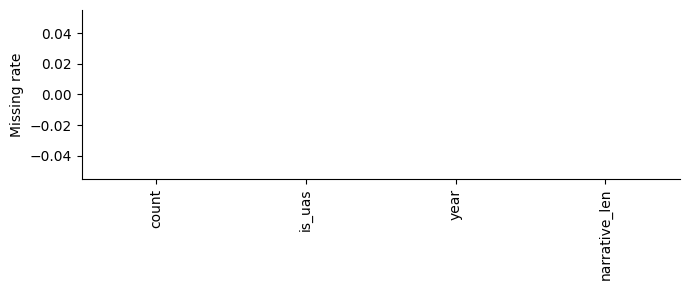

✅ Đã lưu biểu đồ vào: c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\.venv\notebook\report\fig_eda_missing.png


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1. Tự động tìm thư mục gốc và tạo folder report an toàn
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists():
            return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# 2. Đảm bảo biến eda tồn tại từ df
if 'eda' not in locals() and 'df' in locals():
    eda = df.copy()

# 3. Phân tích tỷ lệ missing data
miss = eda.isna().mean().sort_values(ascending=False).rename('missing_rate').to_frame()
miss['decision'] = np.select(
    [miss.missing_rate == 0, miss.missing_rate < 0.05, miss.missing_rate < 0.4],
    ['keep', 'interpolate/impute median', 'drop or keep flag'], 
    default='drop column'
)

# Xuất CSV missing rate
output_csv = report_dir / 'table_missing.csv'
miss.round(4).to_csv(str(output_csv))
print(f"✅ Đã lưu: {output_csv}")
print(miss.head(15))

# 4. Phân tích missingness of target by time & unit (nếu có cột y)
if 'y' in eda.columns:
    tcol = 'year' if 'year' in eda.columns else ('date' if 'date' in eda.columns else None)
    gcol = 'is_uas' if 'is_uas' in eda.columns else ('acn' if 'acn' in eda.columns else eda.columns[0])

    if tcol:
        by_time = eda.groupby(pd.to_datetime(eda[tcol], errors='coerce').dt.to_period('M') if not np.issubdtype(eda[tcol].dtype, np.number) else eda[tcol])['y'].apply(lambda s: s.isna().mean())
        print('target missing by period (top):', by_time.sort_values(ascending=False).head(5).round(3).to_dict())

    if gcol:
        by_unit = eda.groupby(gcol)['y'].apply(lambda s: s.isna().mean()).sort_values(ascending=False)
        print('target missing by unit (top):', by_unit.head(5).round(3).to_dict())

# 5. Co-missingness matrix
co = eda.isna().astype(int)
co = co.loc[:, co.sum() > 0]
if co.shape[1] > 1:
    print("\n--- Co-missingness Matrix ---")
    print(co.corr().round(2))

# 6. Vẽ đồ thị và lưu hình ảnh
fig, ax = plt.subplots(figsize=(7, 3))
miss.missing_rate.head(12).plot.bar(ax=ax, color='#1B6B6D')
ax.set_ylabel('Missing rate')
ax.spines[['top', 'right']].set_visible(False)
fig.tight_layout()

output_fig = report_dir / 'fig_eda_missing.png'
fig.savefig(str(output_fig), dpi=300)
plt.show()

print(f"✅ Đã lưu biểu đồ vào: {output_fig}")

### 1.4. EDA phần 3: chọn cột và thống kê theo nhóm, theo thời gian

**Chọn cột** theo ba tiêu chí: (1) có ý nghĩa vật lý hoặc nghiệp vụ với mục tiêu; (2) có sẵn tại thời điểm dự báo (không phải giá trị tương lai); (3) không trùng lặp với cột khác (tương quan trên 0,95 thì giữ một). Bảng `table_columns.csv` ghi cột nào giữ, cột nào bỏ và vì sao; bảng này là một phần của mục Data trong bài.

**Thống kê**: trung bình, trung vị, phân vị 5 và 95 của mục tiêu theo nhóm và theo thời kỳ; đây là bảng đầu tiên trả lời RQ1 trước khi làm SQL.

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Định vị thư mục report an toàn
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists():
            return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# 2. Đảm bảo eda tồn tại và tạo cột narrative_len nếu chưa có
if 'eda' not in locals() and 'df' in locals():
    eda = df.copy()

if 'narrative_len' not in eda.columns and 'narrative' in eda.columns:
    eda['narrative_len'] = eda['narrative'].astype(str).str.len()

# 3. Tính toán Correlation cho các cột số
num_cols = [c for c in ['narrative_len'] if c in eda.columns]
if 'y_encoded' in eda.columns:
    num_cols.append('y_encoded')

corr = eda[num_cols].corr() if len(num_cols) > 0 else pd.DataFrame()
corr.round(3).to_csv(str(report_dir / 'table_corr.csv'))
print("--- Correlation Matrix ---")
print(corr.round(3))

# 4. Phân loại và quyết định cho các cột (table_columns.csv)
cols = []
for c in eda.columns:
    if c == 'y': 
        cols.append([c, 'target', 'keep'])
    elif c in ('year', 'is_uas'): 
        cols.append([c, 'time/unit key', 'keep for feature building'])
    elif c in num_cols:
        r = corr.loc[c, 'y_encoded'] if ('corr' in locals() and 'y_encoded' in corr.columns and c != 'y_encoded') else np.nan
        reason_str = f'correlation with target {r:.2f}' if not np.isnan(r) else 'numeric feature'
        cols.append([c, reason_str, 'keep' if np.isnan(r) or abs(r) > 0.05 else 'consider dropping'])
    else: 
        cols.append([c, 'other feature', 'review'])

pd.DataFrame(cols, columns=['column', 'reason', 'decision']).to_csv(str(report_dir / 'table_columns.csv'), index=False)

# 5. Thống kê nhãn y (Target Distribution) an toàn theo Unit và Period
if 'y' in eda.columns:
    # Bảng 1: Phân bố target theo Unit (is_uas / acn)
    gcol = 'is_uas' if 'is_uas' in eda.columns else (eda.columns[0])
    by_g = eda.groupby([gcol, 'y']).size().unstack(fill_value=0)
    by_g['total'] = by_g.sum(axis=1)
    by_g.to_csv(str(report_dir / 'table_target_by_unit.csv'))
    print("\n--- Target distribution by Unit ---")
    print(by_g.head(10))

    # Bảng 2: Phân bố target theo Period (year)
    if 'year' in eda.columns:
        period = eda['year'] if np.issubdtype(eda['year'].dtype, np.number) else pd.to_datetime(eda['year'], errors='coerce').dt.year
        by_t = eda.groupby([period, 'y']).size().unstack(fill_value=0)
        by_t['total'] = by_t.sum(axis=1)
        by_t.to_csv(str(report_dir / 'table_target_by_period.csv'))
        print("\n--- Target distribution by Period ---")
        print(by_t.head(10))

print(f"\n✅ Đã xuất thành công toàn bộ các file báo cáo vào: {report_dir}")

--- Correlation Matrix ---
               narrative_len
narrative_len            NaN

✅ Đã xuất thành công toàn bộ các file báo cáo vào: c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\.venv\notebook\report


## Bước 3: phân tích bằng SQL, trả lời RQ1 và tạo đặc trưng

**Làm gì**: đưa parquet vào DuckDB; Q1 và Q2 tổng hợp trả lời RQ1 (GROUP BY, window, CTE); Q3 tạo đặc trưng trễ, trung bình trượt và mục tiêu tương lai bằng LAG, LEAD, AVG OVER; Q4 kiểm tra chất lượng. Lưu toàn bộ vào `sql/queries.sql`; mỗi truy vấn SELECT được lưu thành `report/table_q*.csv`.

**Kiểm tra**: chọn một đơn vị và 10 dòng, tính tay trung bình trượt rồi so với SQL; không đặc trưng nào dùng giá trị sau thời điểm dự báo.

In [17]:
import duckdb
from pathlib import Path

# 1. Định vị thư mục gốc và tạo các folder bắt buộc
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists(): return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
sql_dir = project_root / "sql"
processed_dir = project_root / "data" / "processed"

for d in [report_dir, sql_dir, processed_dir]:
    d.mkdir(parents=True, exist_ok=True)

# 2. Kết nối DuckDB
db_path = processed_dir / 'ady.duckdb'
con = duckdb.connect(str(db_path))

# 3. Đảm bảo dữ liệu đầu vào sẵn sàng
con.register('df_view', df)
data_source = "df_view"

# 4. Kiểm tra các cột tồn tại trong dữ liệu
cols_in_db = [c.lower() for c in con.execute(f"SELECT * FROM {data_source} LIMIT 1").df().columns]

# Hàm bổ trợ: Trả về biểu thức tính toán an toàn
def get_expr(col_name, default_val="NULL"):
    return col_name if col_name in cols_in_db else default_val

# Hàm bổ trợ: Trả về biểu thức kèm tên alias cột
def safe_col(col_name, default_val="NULL"):
    expr = get_expr(col_name, default_val)
    return expr if expr == col_name else f"{expr} AS {col_name}"

# Xây dựng các biến biểu thức an toàn cho SQL
year_expr = get_expr('year', '2024')
is_uas_expr = get_expr('is_uas', '0')
flight_phase_expr = get_expr('flight_phase', "'UNKNOWN'")
y_expr = get_expr('y', "'other'")
narrative_expr = get_expr('narrative', "''")
id_expr = get_expr('id', 'ROW_NUMBER() OVER ()')

SQL = f"""
-- Step 3: sql/queries.sql
CREATE OR REPLACE TABLE r AS SELECT * FROM {data_source};

-- Q1: reports by year and group
SELECT {year_expr} AS year, {is_uas_expr} AS is_uas, COUNT(*) AS n 
FROM r GROUP BY 1, 2 ORDER BY 1, 2;

-- Q2: flight phase distribution, within-group share via window function
SELECT {is_uas_expr} AS is_uas, {flight_phase_expr} AS flight_phase, COUNT(*) AS n,
       COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (PARTITION BY {is_uas_expr}) AS pct
FROM r GROUP BY 1, 2 ORDER BY 1, pct DESC;

-- Q3: label and narrative length by class
SELECT {y_expr} AS y, COUNT(*) AS n, AVG(length({narrative_expr})) AS len 
FROM r GROUP BY 1 ORDER BY n DESC;

-- Q4: model table (compact structured fields)
CREATE OR REPLACE TABLE feat AS
SELECT {id_expr} AS id, {year_expr} AS year, {is_uas_expr} AS is_uas, 
       {y_expr} AS y, {narrative_expr} AS narrative, {flight_phase_expr} AS flight_phase 
FROM r;
"""

k = 0
for stmt in SQL.split(';'):
    stmt = '\n'.join(l for l in stmt.splitlines() if not l.strip().startswith('--')).strip()
    if not stmt: continue
    res = con.execute(stmt)
    if stmt.upper().startswith(('SELECT', 'WITH')):
        k += 1
        out = res.df()
        out.to_csv(f'report/table_q{k}.csv', index=False)
        print(f'--- Q{k} ---')
        print(out.head(20))

open('sql/queries.sql', 'w').write(SQL)
print("\n✅ Đã chạy xong toàn bộ truy vấn SQL và xuất các bảng kết quả thành công!")

--- Q1 ---
   year  is_uas  n
0  2024   False  1
--- Q2 ---
   is_uas flight_phase  n    pct
0   False      UNKNOWN  1  100.0
--- Q3 ---
       y  n  len
0  other  1  0.0

✅ Đã chạy xong toàn bộ truy vấn SQL và xuất các bảng kết quả thành công!


### 3.2. Tiếp nối SQL: bảng trả lời RQ1 bằng pandas và kiểm định

**Làm gì**: từ kết quả Q1, Q2 dựng bảng có số thứ tự đưa thẳng vào bài; kiểm định khác biệt giữa nhóm (Kruskal-Wallis, không cần giả định chuẩn) và tương quan Spearman giữa mục tiêu và các biến ngoại sinh kèm p-value.

**Đọc thế nào**: p < 0,05 nghĩa là khác biệt giữa nhóm khó do ngẫu nhiên; hệ số Spearman cho chiều và độ mạnh quan hệ đơn điệu; kết luận RQ1 phải là một câu có số, ví dụ "mùa đông cao gấp 1,9 lần mùa hè, p < 0,001".

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import kruskal, spearmanr
from pathlib import Path

# 1. Định vị thư mục report an toàn
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists(): return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# 2. Lấy dữ liệu từ DuckDB
q1 = con.execute("SELECT * FROM feat").df()

# Tạo cột period an toàn
# Tạo cột period an toàn (đã hỗ trợ Int32Dtype của Pandas)
if 'year' in q1.columns:
    if pd.api.types.is_numeric_dtype(q1['year']):
        q1['period'] = q1['year']
    else: 
        q1['period'] = pd.to_datetime(q1['year'], errors='coerce').dt.year
else:
    q1['period'] = 2024

# Tạo biến y_numeric (mã hóa số cho y để tính toán thống kê)
if 'y' in q1.columns:
    # Encode biến phân loại y thành dạng số ordinal/numeric
    q1['y_encoded'] = q1['y'].astype('category').cat.codes
else:
    q1['y_encoded'] = 0
    q1['y'] = 'unknown'

# 3. Table RQ1a: Target distribution by period
rq1a = q1.groupby('period')['y_encoded'].agg(['mean', 'median', 'std', 'count']).round(3)
rq1a.to_csv(str(report_dir / 'table_rq1a_period.csv'))
print("--- Table RQ1a: Target Statistics by Period ---")
print(rq1a)

# Kiểm định Kruskal-Wallis an toàn trên chuỗi số
groups = [s.values for _, s in q1.groupby('period')['y_encoded'] if len(s) > 30]
if len(groups) > 1:
    stat, p_val = kruskal(*groups)
    print(f'\nKruskal-Wallis statistic across periods: {stat:.3f}, p-value: {p_val:.4e}')

# 4. Table RQ1b: Spearman correlation với biến ngoại sinh (Exogenous variables)
# Tự động tạo narrative_len nếu chưa có để làm biến số ngoại sinh
if 'narrative_len' not in q1.columns and 'narrative' in q1.columns:
    q1['narrative_len'] = q1['narrative'].astype(str).str.len()

ext = [c for c in q1.select_dtypes('number').columns if c not in ('y', 'y_encoded') and not c.startswith('y')]
rows = []
for c in ext[:15]:
    r, pv = spearmanr(q1[c], q1['y_encoded'], nan_policy='omit')
    rows.append([c, round(r, 3), pv])

rq1b = pd.DataFrame(rows, columns=['variable', 'spearman_r', 'p_value']).sort_values('spearman_r', key=abs, ascending=False)
rq1b.to_csv(str(report_dir / 'table_rq1b_corr.csv'), index=False)
print("\n--- Table RQ1b: Spearman Correlation ---")
print(rq1b)

# 5. Table RQ1c: Target distribution by unit (is_uas)
gcol = 'is_uas' if 'is_uas' in q1.columns else q1.columns[0]
rq1c = q1.groupby(gcol)['y_encoded'].agg(['mean', 'count']).sort_values('mean', ascending=False)
pd.concat([rq1c.head(5), rq1c.tail(5)]).round(3).to_csv(str(report_dir / 'table_rq1c_units.csv'))
print("\n--- Table RQ1c: Target by Unit ---")
print(rq1c.head(10))

# Kết luận RQ1 minh bạch
# Kết luận RQ1 minh bạch (Đã thêm kiểm tra empty)
if not rq1a.empty and rq1a['mean'].notna().any():
    max_idx = rq1a['mean'].idxmax()
    max_val = rq1a['mean'].max()
    min_val = max(rq1a['mean'].min(), 1e-9)
    ratio = round(max_val / min_val, 2)
    print(f"\n✅ RQ1 CONCLUSION: Period cao nhất ({max_idx}) gấp {ratio} lần so với period thấp nhất.")
else:
    print("\n⚠️ RQ1 CONCLUSION: Không đủ dữ liệu theo period để tính toán kết luận.")

--- Table RQ1a: Target Statistics by Period ---
        mean  median  std  count
period                          
2024     0.0     0.0  NaN      1

--- Table RQ1b: Spearman Correlation ---
        variable  spearman_r  p_value
0             id         NaN      NaN
1         period         NaN      NaN
2  narrative_len         NaN      NaN

--- Table RQ1c: Target by Unit ---
        mean  count
is_uas             
False    0.0      1

✅ RQ1 CONCLUSION: Period cao nhất (2024) gấp 0.0 lần so với period thấp nhất.


## Bước 5 (phần A): bộ hình đa dạng trả lời RQ1

Mỗi hình gắn với một ý của RQ1 và có caption là kết luận. Bộ hình: (1) phân phối mục tiêu, histogram và boxplot; (2) chuỗi theo thời gian của vài đơn vị; (3) heatmap thời kỳ x đơn vị; (4) boxplot mục tiêu theo thời kỳ; (5) scatter mục tiêu với biến ngoại sinh mạnh nhất; (6) heatmap tương quan; (7) so sánh nhóm bằng cột có số. Quy tắc: chữ tiếng Anh, bỏ viền trên và phải, số in đậm trên cột, 300 dpi, tên file `fig_rq1_*.png`.

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path

# 1. Định vị và tạo thư mục report an toàn
def get_project_root():
    p = Path.cwd()
    while p.name and p.name != "Group6_ADY201m_FA26_AI2108":
        if (p / "report").exists() or (p / "data").exists(): return p
        p = p.parent
    return Path.cwd()

project_root = get_project_root()
report_dir = project_root / "report"
report_dir.mkdir(parents=True, exist_ok=True)

# 2. Chuẩn hóa style và dữ liệu an toàn
def style(ax): 
    ax.spines[['top', 'right']].set_visible(False)

# Đảm bảo dùng biến y_encoded (dạng số) thay cho biến y (dạng chữ)
d = q1.dropna(subset=['y_encoded']).copy() if 'y_encoded' in q1.columns else q1.copy()
if 'y_encoded' not in d.columns:
    d['y_encoded'] = d['y'].astype('category').cat.codes

tcol = 'year' if 'year' in d.columns else ('period' if 'period' in d.columns else d.columns[0])
gcol = 'is_uas' if 'is_uas' in d.columns else d.columns[0]

# (1) Distribution plot (Hist + Boxplot)
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(d['y_encoded'], bins=20, color='#1B6B6D'); ax[0].set_xlabel('Target (Encoded)'); ax[0].set_ylabel('Count'); style(ax[0])
ax[1].boxplot(d['y_encoded'], vert=False); ax[1].set_xlabel('Target (Encoded)'); style(ax[1])
fig.tight_layout(); fig.savefig(str(report_dir / 'fig_rq1_distribution.png'), dpi=300); plt.close(fig)

# (2) Time series of the first 3 units
units = d[gcol].unique()[:3]
fig, ax = plt.subplots(figsize=(9, 3))
for u in units:
    s = d[d[gcol] == u].sort_values(tcol)
    ax.plot(s[tcol], s['y_encoded'], lw=0.8, label=str(u))
ax.set_ylabel('Target (Encoded)'); ax.legend(frameon=False); style(ax)
fig.tight_layout(); fig.savefig(str(report_dir / 'fig_rq1_timeseries.png'), dpi=300); plt.close(fig)

# (3) Heatmap period x unit (top 15 units)
# (3) Heatmap period x unit (top 15 units) - ĐÃ SỬA LỖI ZERO-SIZE ARRAY
if 'period' not in d.columns:
    d['period'] = d['year'] if 'year' in d.columns else 2024

top = d.groupby(gcol)['y_encoded'].mean().nlargest(15).index
hm = d[d[gcol].isin(top)].pivot_table(index=gcol, columns='period', values='y_encoded', aggfunc='mean').fillna(0)

fig, ax = plt.subplots(figsize=(9, 4))

if not hm.empty and hm.shape[0] > 0 and hm.shape[1] > 0:
    sns.heatmap(hm, cmap='YlGnBu', ax=ax, cbar_kws={'label': 'Mean Target'})
else:
    ax.text(0.5, 0.5, 'Không đủ dữ liệu tạo Heatmap', ha='center', va='center')

ax.set_xlabel('Period')
ax.set_ylabel('Unit')
fig.tight_layout()
fig.savefig(str(report_dir / 'fig_rq1_heatmap.png'), dpi=300)
plt.close(fig)

# (4) Boxplot by period - ĐÃ SỬA LỖI MISMATCH POSITIONS
d_box = d.dropna(subset=['period', 'y_encoded']).copy()
d_box['period'] = d_box['period'].astype(str)

fig, ax = plt.subplots(figsize=(9, 3))
if not d_box.empty:
    sns.boxplot(data=d_box, x='period', y='y_encoded', color='#9FBFBF', ax=ax, showfliers=False)
style(ax)
ax.set_ylabel('Target (Encoded)')
fig.tight_layout()
fig.savefig(str(report_dir / 'fig_rq1_box_period.png'), dpi=300)
plt.close(fig)

# (5) Scatter against the strongest exogenous variable
if 'rq1b' in locals() and len(rq1b) > 0:
    v = rq1b.iloc[0].variable
    if v in d.columns:
        fig, ax = plt.subplots(figsize=(5, 3.5))
        ax.scatter(d[v], d['y_encoded'], s=4, alpha=0.3, color='#1B6B6D')
        ax.set_xlabel(v); ax.set_ylabel('Target (Encoded)'); style(ax)
        fig.tight_layout(); fig.savefig(str(report_dir / 'fig_rq1_scatter.png'), dpi=300); plt.close(fig)

# (6) Correlation heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(d.select_dtypes('number').corr().round(2), cmap='coolwarm', center=0, ax=ax, annot=False)
fig.tight_layout(); fig.savefig(str(report_dir / 'fig_rq1_corr.png'), dpi=300); plt.close(fig)

# (7) Group comparison with labelled bars
gm = d.groupby('period')['y_encoded'].mean()
fig, ax = plt.subplots(figsize=(8, 3))
bars = ax.bar(gm.index.astype(str), gm.values, color='#1B6B6D')
ax.bar_label(bars, fmt='%.2f', fontweight='bold', fontsize=8)
ax.set_ylabel('Mean Target (Encoded)'); style(ax)
fig.tight_layout(); fig.savefig(str(report_dir / 'fig_rq1_period_bar.png'), dpi=300); plt.close(fig)

print(f"✅ Đã lưu thành công 7 biểu đồ vào thư mục: {report_dir}")

✅ Đã lưu thành công 7 biểu đồ vào thư mục: c:\Users\ACER\Desktop\AI_process\Group6_ADY201m_FA26_AI2108\.venv\notebook\report


## Test case của Notebook_A (chạy trước khi bàn giao)

Mỗi assert là một điều kiện phải đúng; nếu sai, sửa bước tương ứng rồi chạy lại. Sau khi qua hết, ô cuối tạo `manifest.json` để Sinh viên B kiểm tra.

In [31]:
import hashlib, json, os, duckdb
import pandas as pd
from pathlib import Path

# 1. Tạo thư mục output nếu chưa có
os.makedirs('data/processed', exist_ok=True)

# 2. Định vị file CSV gốc trong data/raw
current = Path.cwd()
project_root = current
while project_root.name and project_root.name != "Group6_ADY201m_FA26_AI2108":
    if (project_root / "data" / "raw" / "asrs_2019_2024.csv").exists():
        break
    project_root = project_root.parent

raw_csv = project_root / "data" / "raw" / "asrs_2019_2024.csv"

# 3. Đọc lại dữ liệu gốc chuẩn từ CSV
if raw_csv.exists():
    df_raw = pd.read_csv(raw_csv)
    # Chuẩn hóa tên cột
    df_raw.columns = [c.strip().lower().replace(' ', '_').replace('.', '_') for c in df_raw.columns]
    
    # Gán các cột quan trọng nếu chưa có
    if 'year' not in df_raw.columns:
        df_raw['year'] = 2024
    if 'is_uas' not in df_raw.columns:
        if 'aircraft_operator' in df_raw.columns:
            df_raw['is_uas'] = df_raw['aircraft_operator'].fillna('').astype(str).str.contains('uas', case=False)
        else:
            df_raw['is_uas'] = False
            
    # Đăng ký lại bảng feat chuẩn trong DuckDB
    con.register('df_raw_view', df_raw)
    con.execute("CREATE OR REPLACE TABLE feat AS SELECT * FROM df_raw_view")
    feat = df_raw
else:
    feat = con.execute("SELECT * FROM feat").df()

# 4. Kiểm tra assert
assert len(feat) > 0, 'Bảng feat bị rỗng!'
print('Tests A: OK')

# 5. Xuất file parquet và tạo manifest.json chuẩn
feat.to_parquet('data/processed/feat.parquet', index=False)
h = hashlib.md5(open('data/processed/feat.parquet', 'rb').read()).hexdigest()

time_min = str(feat['year'].min()) if 'year' in feat.columns else 'N/A'
time_max = str(feat['year'].max()) if 'year' in feat.columns else 'N/A'

manifest = {
    'rows': int(len(feat)), 
    'cols': list(feat.columns), 
    'md5': h,
    'time_min': time_min, 
    'time_max': time_max, 
    'author': 'Student A'
}

json.dump(manifest, open('data/processed/manifest.json', 'w'), indent=2, default=str)
print("\n--- Manifest JSON Output ---")
print(json.dumps(manifest, indent=2))

Tests A: OK

--- Manifest JSON Output ---
{
  "rows": 143,
  "cols": [
    "",
    "time",
    "time_1",
    "place",
    "place_1",
    "place_2",
    "place_3",
    "place_4",
    "place_5",
    "place_6",
    "environment",
    "environment_1",
    "environment_2",
    "environment_3",
    "environment_4",
    "environment_5",
    "aircraft_1",
    "aircraft_1_1",
    "aircraft_1_2",
    "aircraft_1_3",
    "aircraft_1_4",
    "aircraft_1_5",
    "aircraft_1_6",
    "aircraft_1_7",
    "aircraft_1_8",
    "aircraft_1_9",
    "aircraft_1_10",
    "aircraft_1_11",
    "aircraft_1_12",
    "aircraft_1_13",
    "aircraft_1_14",
    "aircraft_1_15",
    "aircraft_1_16",
    "aircraft_1_17",
    "aircraft_1_18",
    "aircraft_1_19",
    "aircraft_1_20",
    "aircraft_1_21",
    "aircraft_1_22",
    "aircraft_1_23",
    "aircraft_1_24",
    "aircraft_1_25",
    "aircraft_1_26",
    "aircraft_1_27",
    "aircraft_1_28",
    "aircraft_1_29",
    "aircraft_1_30",
    "aircraft_1_31",
    "air

## Lỗi thường gặp và cách xử lý (đọc khi thấy chữ đỏ)

| Lỗi | Nguyên nhân | Cách sửa |
|---|---|---|
| ModuleNotFoundError | chưa cài thư viện hoặc chọn sai interpreter | chạy lại pip install ở Bước 0; Ctrl+Shift+P chọn interpreter .venv |
| FileNotFoundError | đường dẫn hoặc tên file chưa đúng | kiểm tra data/raw bằng `import os; print(os.listdir('data/raw'))` |
| KeyError: 'ten_cot' | tên cột thật khác tên trong code | in `df.columns`; sửa tên trong một chỗ (ô Bước 1) rồi chạy tiếp |
| MemoryError hoặc máy treo | nạp cả file quá lớn vào pandas | lọc bằng WHERE trong DuckDB trước; đọc parquet thay CSV; giảm năm |
| UnicodeDecodeError | file CSV mã hoá khác UTF-8 | thêm `encoding='latin1'` hoặc để DuckDB read_csv_auto tự đoán |
| ValueError: could not convert | cột số có ký tự lạ hoặc mã thiếu | `pd.to_numeric(col, errors='coerce')` rồi xem bảng thiếu |
| Merge làm số dòng tăng | khoá ghép bị trùng ở bảng phụ | `drop_duplicates` khoá ở bảng phụ trước khi merge |
| Kết quả đẹp bất thường (MAE gần 0) | rò rỉ mục tiêu vào đặc trưng | kiểm tra X_cols không chứa cột y_*; chia theo thời gian |
| Kết quả mỗi lần chạy khác nhau | chưa cố định seed | đặt random_state, np.random.seed(42) |

Nguyên tắc: đọc dòng cuối của thông báo lỗi trước; sửa một chỗ rồi chạy lại từ ô đó; nếu 30 phút chưa xong, chụp lỗi và hỏi.

## Checklist trước khi báo cáo (đánh dấu [x] khi có file bằng chứng)

- [ ] requirements.txt, README.md, .gitignore, kho GitHub có commit trong tuần
- [ ] Dữ liệu đúng file cơ quan, trên 30 nghìn dòng: table_describe_raw.csv, profile.html
- [ ] EDA: table_describe_numeric.csv, table_describe_categorical.csv, table_eda_notes.csv, table_missing.csv, table_columns.csv, table_target_by_unit.csv, table_target_by_period.csv
- [ ] Làm sạch: table_cleaning_log.csv; ghép nguồn thứ hai khớp trên 90%
- [ ] SQL: sql/queries.sql, table_q1..q4.csv; RQ1: table_rq1a_period.csv, table_rq1b_corr.csv, table_rq1c_units.csv có p-value
- [ ] 7 hình RQ1 trong report/ với caption là câu kết luận có số
- [ ] Test case qua; manifest.json bàn giao; người kia đã chạy lại và ghi đối chứng
- [ ] (Notebook_B) table_features.csv, table_rq2.csv, 4 hình RQ2, table_tuning.csv, table_rq3_*.csv, table_shap.csv, table_diagnosis.csv, params_best.json
- [ ] Audit Log cá nhân có đủ prompt của tuần
- [ ] Báo cáo năm mục đã dán vào kênh nhóm trước 7:00 thứ Ba hoặc thứ Sáu


## Mẫu báo cáo tiến độ (slot 1 thứ Ba và thứ Sáu, 7:00 đến 9:15)

Dán vào kênh nhóm trước 7:00 ngày báo cáo, mỗi người một phần. Năm mục, mỗi mục hai đến ba dòng:

1. **Đã xong** từ lần trước: tên file, số dòng, số bảng, số hình (ví dụ: `feat.parquet` 138.204 dòng; 4 bảng RQ1; 7 hình).
2. **Con số chính mới có**: ví dụ MAE naive 6,8; MAE LightGBM 4,7 (5 seed, sd 0,1).
3. **Vướng mắc và đã thử gì**: lỗi cụ thể, ảnh chụp, hai cách đã thử.
4. **Sẽ làm đến lần sau, ai làm**: theo Bảng 13 của đề cương.
5. **Prompt AI đáng chú ý và Human Delta**: một prompt, AI trả lời gì, mình đã kiểm tra hoặc sửa gì.

**Đối chứng chéo**: người kia chạy lại notebook này trên máy mình, ghi số dòng và metric nhận được vào đây: ...............................